In [7]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict


In [45]:
class basestate(TypedDict):
    runs : int
    ball : int
    four : int
    sixes : int
    
    sr : float
    bpb : float
    boundry_boxes : float
    summary:str

In [47]:
def calculate_runs(state:basestate):
    runs = state["runs"] / state["ball"] + 20
    return {"runs": runs}

In [49]:
def calculate_ball(state:basestate):
    balls = state['ball'] +100/ state["runs"]
    return {"ball": balls}

In [51]:
def calculate_strike(state:basestate):
    srd = state["sr"] + state["bpb"] *state["four"]/100
    return {"sr":srd}

In [53]:
def calculate_summary(state: basestate):
    print("Summary organizeD ..........    ")
    summ = f"""
    Runs of - :{state['runs']}\n,
    Balls of  - : {state["ball"]}\n,
    Strike Rate of - :{state["sr"]}\n,
             """
    return {"summary":summ}

In [55]:
graph = StateGraph(basestate)

# add nodes 
graph.add_node("calculate_runs", calculate_runs),
graph.add_node("calculate_ball", calculate_ball)
graph.add_node("calculate_strike", calculate_strike)
graph.add_node("calculate_summary", calculate_summary)

In [57]:
# add edges
graph.add_edge(START, "calculate_runs")
graph.add_edge(START, "calculate_ball")
graph.add_edge(START, "calculate_strike")

graph.add_edge("calculate_runs", "calculate_summary")
graph.add_edge("calculate_ball", "calculate_summary")
graph.add_edge("calculate_strike", "calculate_summary")

graph.add_edge("calculate_summary", END)

In [41]:
workflow = graph.compile()

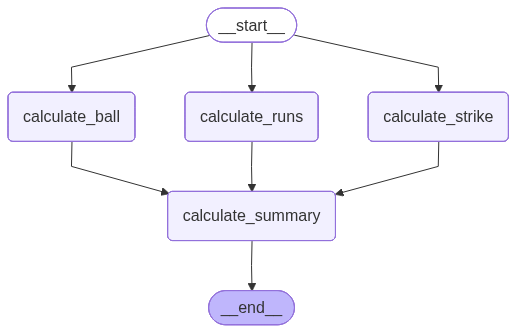

In [61]:
workflow

In [69]:
initial_state = {
    "runs": 45,
    "ball": 30,
    "four": 5,
    "sixes": 2,
    "sr": 140.0,
    "bpb": 3.5,
    "boundry_boxes": 0,
    "summary": ""
}
final_state = workflow.invoke(initial_state)

# Step 9: Print Results
print("\n Final State:")
print(final_state)
# print("\nSummary Text:")
# print(final_state["calculate_summary"])

Summary organizeD ..........    

 Final State:
{'runs': 21.5, 'ball': 32.22222222222222, 'four': 5, 'sixes': 2, 'sr': 140.175, 'bpb': 3.5, 'boundry_boxes': 0, 'sumary': '\n    Runs of - :21.5\n,\n    Balls of  - : 32.22222222222222\n,\n    Strike Rate of - :140.175\n,\n             '}
